In [ ]:
### IMPORTS

!pip install scikit_posthocs
!pip install adjustText
!pip install ipython-autotime

%load_ext autotime

import string
import numpy as np
import pandas as pd
import math
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy.stats as ss
import scikit_posthocs as scihoc
import seaborn as sns

from matplotlib import patches
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from adjustText import adjust_text
from os import listdir
from random import choice
from re import search, escape, sub
from scipy import integrate
# from statannotations.Annotator import Annotator


import gspread
from google.colab import auth, drive
from google.auth import default
auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)
drive.mount('/content/gdrive/', force_remount=True)

In [ ]:
### PATH

experiment_to_analyse = '' # INSERT HERE NAME OF EXPERIMENT
path = f"" # INSERT HERE PATH TO DATA

time: 415 µs (started: 2025-02-10 11:14:21 +00:00)


In [ ]:
### COLOR SCHEMES

colordict = {'Brassica': '#8d8089',
             'Pelt': '#50414c',
             'Brinjal': '#5e3a42',
             'Middleton Pink': '#fde7e5',
             'Calluna': '#ccc8ce',
             'Sugaroom Red': '#d0bfcd',
             'Preference Red': '#6d4247',
             'Sulking Room Pink': "#a0837f",
             'Cinder Rose': "#c6a4a6",
             'Nancys Blushes': "#ecb7b8",
             'Rangwali': "#bf7a8f",
             'Lake Red': "#c8526a",
             'Rectory Red': "#a53c49",
             'Incarnadine': "#a04344",
             'Blazer': "#b64f48",
             'Harissa': "#ae5043",
             'Charlottes Locks': "#d65f3d",
             'Book Room': "#ab6758",
             'Red Earth': "#c57b67",
             'India Yellow': "#cb9e59",
             'Sudbury Yellow': "#dcb771",
             'Babouche': "#ecc363",
             'Yellowcake': "#ebe05e",
             'Yellow Ground': "#f2cf86",
             'Dayroom Yellow': "#f7e29d",
             'Dorset Cream': "#efd5a1",
             'Tallow': "#fdedd7",
             'Farrows Cream': "#efdbb3",
             'Hay': "#dec795",
             'Citrona': "#dbcc7c",
             'Churlish Green': "#c8bd83",
             'Yeabridge Green': "#909e6e",
             'Bancha': "#686a47",
             'Duck Green': "#465741",
             'Green Ground': "#dbdab6",
             'Cooking Apple Green': "#c4c6a5",
             'Lichen': "#a1a189",
             'Breakfast Room Green': "#94a68a",
             'Calke Green': "#758769",
             'Emerald Green': "#7bae72",
             'Verdigris': "#3e8b67",
             'Vardo': "#427e83",
             'Arsenic': "#84b59c",
             'Green Smoke': "#737c70",
             'Oval Room Blue': "#8b9d9b",
             'Green Blue': "#acbdb2",
             'Dix Blue': "#99b0ab",
             'Parma Gray': "#b1bfc5",
             'Blue Ground': "#a1c5c8",
             'Stone Blue': "#7997a1",
             'Inchyra Blue': "#586768",
             'Hague Blue': "#3d4e57",
             'Stiffkey Blue': "#4d5b6a",
             'St Giles Blue': "#599ec4",
             'Ultra Marine Blue': "#5d82a1",
             'Cooks Blue': "#6a90b4",
             'Lulworth Blue': "#a0b8c8",
             'Pitch Blue': "#636e8f",
             'Imperial Purple': "#55566b",
             'Scotch Blue': "#41404c",
             'Paean Black': "#494248",
             'Railings': "#45494b",
             'Off Black': "#444546",
             'Pitch Black': "#3b3938",
             'Pigeon': "#a0a093",
             'Old White': "#cec3ad",
             'Strong White': "#e5e0db",
             'Cabbage White': "#e8eeea"}

time: 1.41 ms (started: 2025-02-10 11:14:22 +00:00)


In [ ]:
filename = '' ### INSERT HERE NAME OF FILE WITH EXTRACTED VALUES FROM IVIS IMAGER

file = pd.ExcelFile(f'{path}{filename}')
data = pd.DataFrame()

print(f'file: {filename}')
for sheet_num, sheet_name in enumerate(file.sheet_names[:]):
  print(f'{sheet_num}: {sheet_name}')

  raw_data = pd.read_excel(file, sheet_name = sheet_name)
  raw_data.set_index('Unnamed: 0', inplace = True)
  bg = raw_data.iloc[12:, :].dropna(axis = 1)
  bg = bg.astype('float')

  raw_data = raw_data.dropna(axis = 0)
  raw_data = raw_data.loc[:, ~(raw_data == 'ignored').any()]
  raw_data = raw_data.astype('float')

  raw_data = raw_data.apply(lambda col: col-bg.mean(axis = 1), axis = 0)
  raw_data = raw_data.transpose()
  raw_data['Sum'] = raw_data.sum(axis = 1)
  raw_data = raw_data.merge(order, how = 'inner', left_index = True, right_on = 'Well')
  raw_data['Sheet_name'] = sheet_name

  data = pd.concat([data, raw_data])

data.reset_index(inplace = True, drop = True)

data_norm = pd.DataFrame()
for index, row in data.iterrows():
    norm_value = row[540.0]
    if norm_value == 'ignored' or norm_value == 'Ignored':
      continue
    else:
      modified_row = np.divide(row[:-4].values.tolist(), norm_value)

      modified_row = pd.DataFrame(pd.concat([pd.Series(modified_row), row[-4:]])).transpose()
      data_norm = pd.concat([data_norm, modified_row], axis = 0)
data_norm.columns = data.columns

data_norm.to_csv(f'{path}{experiment_to_analyse}_ivis_full_data_533nm_normalized_sum_all_not_norm.csv', index = False)
data_norm

file: nouka194_3_17.01.2025_ivis.xlsx
0: Plate1
1: Plate2
2: Plate3
3: Plate4
4: Plate5
5: Plate6
6: Plate7
7: Plate8


,500.0,520.0,540.0,560.0,580.0,600.0,620.0,640.0,660.0,680.0,700.0,Sum,Well,Label,Sheet_name
0,0.553054,0.968311,1.0,0.811156,0.675733,0.841192,1.146703,1.174089,0.944012,0.646161,0.414335,3620.3404,A1,(GGGGS)1—(GGGGS)1,Plate1
0,0.548679,0.979112,1.0,0.828322,0.709675,0.882824,1.226648,1.245743,0.996129,0.681181,0.451009,3430.8274,A2,SGLRS—(GGGGS)1,Plate1
0,0.561721,0.96748,1.0,0.805474,0.662557,0.790304,1.046602,1.053459,0.836927,0.570548,0.371785,3512.6894,A3,(GGGGS)3—(GGGGS)1,Plate1
0,0.567206,0.97923,1.0,0.801632,0.657649,0.751152,0.994039,0.999027,0.775777,0.523948,0.344957,4267.4494,A4,OD-linker—(GGGGS)1,Plate1
0,0.573958,0.976811,1.0,0.817447,0.663548,0.759486,0.996858,1.001867,0.766539,0.538664,0.343061,4727.5024,A5,GHGTGSTGSGSSAS—(GGGGS)1,Plate1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,2.625806,-11.632258,1.0,25.232258,-5.522581,-9.341935,8.535484,6.23871,14.516129,17.309677,18.316129,-2.0856,H8,empty,Plate8
0,0.939568,0.951559,1.0,-0.808393,-1.155635,-0.851799,-0.836451,-0.03765,-0.021583,-0.254916,-1.101679,-1.8156,H9,empty,Plate8
0,-0.593154,-1.211736,1.0,1.582396,1.498289,0.150122,0.250856,0.670905,0.242054,-0.60489,0.728117,-1.5186,H10,empty,Plate8
0,0.652886,0.017877,1.0,0.656983,-1.895345,0.137058,-0.947114,-0.25959,-1.240223,0.460708,-0.7054,-1.1396,H11,empty,Plate8


time: 3.2 s (started: 2025-01-25 19:37:19 +00:00)


In [ ]:
replace_dict = {
    ' -': '-',
    '- ': '-',
    'Luz v5': 'Luz_v5',
    ' 2 aa linkers': ' (2 aa linkers)',
    '((2 aa linkers))': '(2 aa linkers)',
    '(from tdTomato)': '',
    ' – ': '-',
    '—': '-',
    'w/o': 'without',
    'ins167 m': 'ins167-m',
    'ins188 m': 'ins188-m',
} # Example dict for labels corrections
replace_pattern = '|'.join(sorted(escape(k) for k in replace_dict))

time: 928 µs (started: 2025-02-10 11:40:39 +00:00)


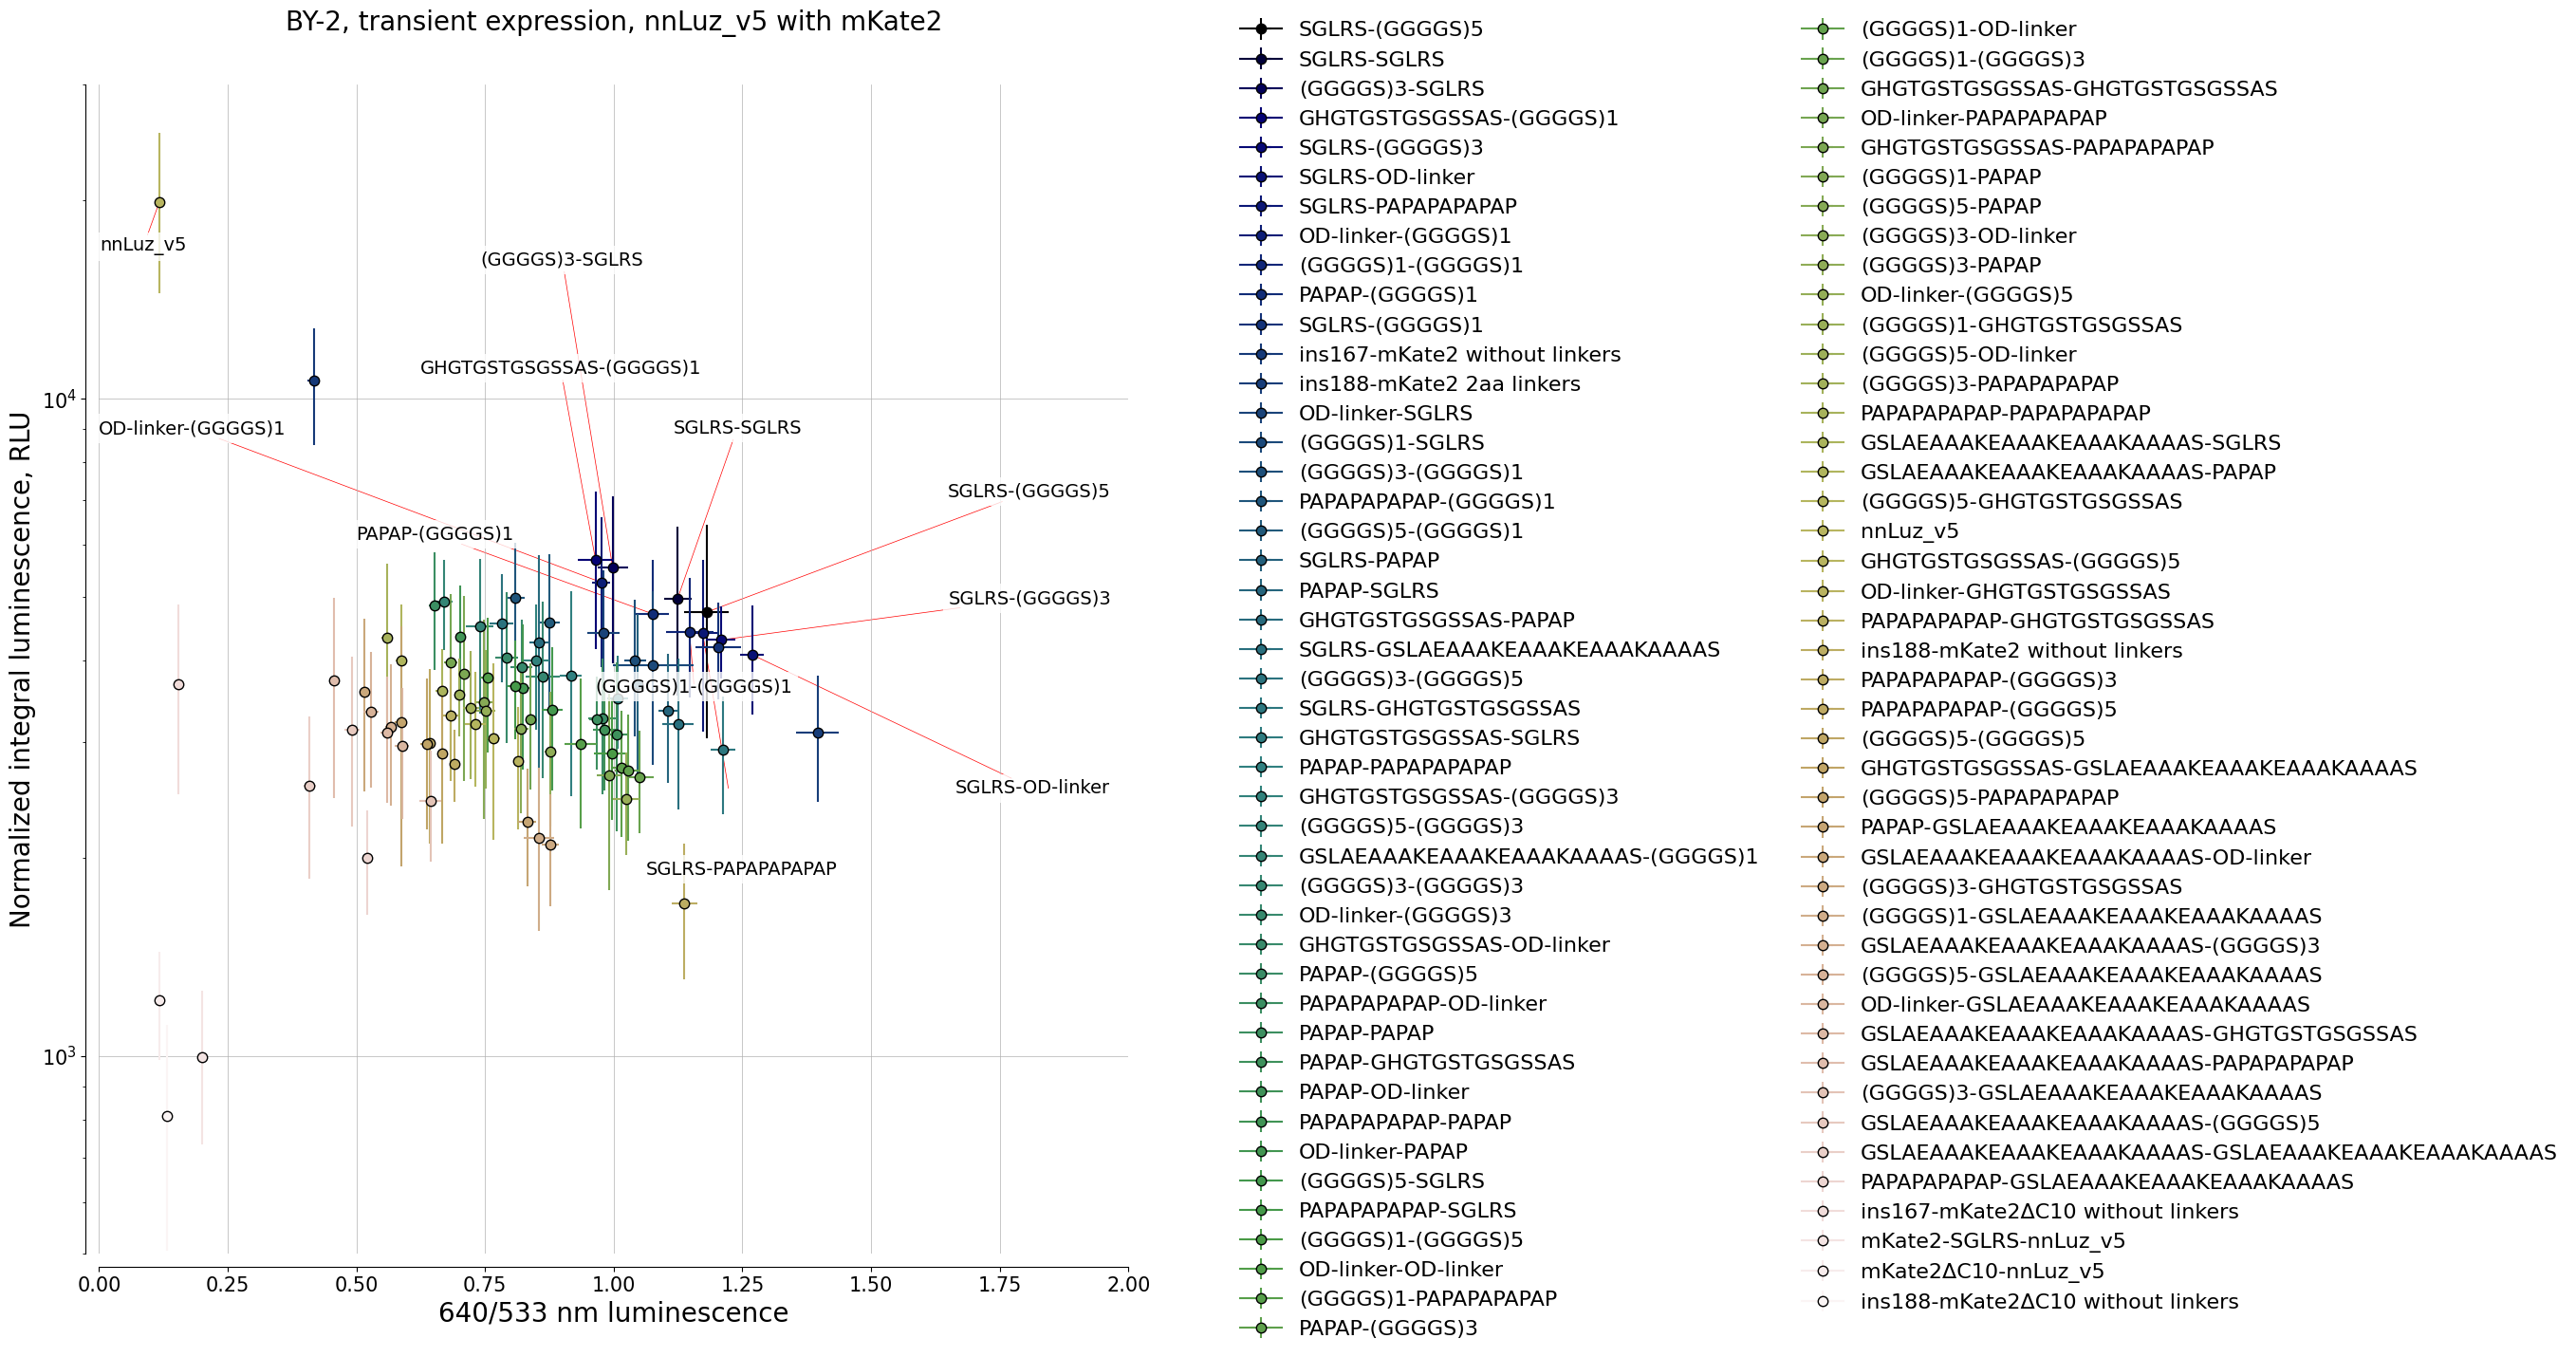

time: 20.1 s (started: 2025-02-10 11:47:31 +00:00)


In [ ]:
prot_filter = 'mKate2'

xlabel_size = 20
ylabel_size = 20
yticklabel_size = 15
xticklabel_size = 15
title_size = 24
suptitle_size = 20
legend_size = 16
signplot_size = 15
instick_size = 9


full_data = pd.read_csv(f'{path}{experiment_to_analyse}_ivis_full_data_533nm_normalized_sum_all_not_norm.csv')
full_data = full_data[(full_data.Label != 'Ignored') & (full_data.Label != 'ignored')& (full_data.Label != 'empty')]
full_data['Label'] = full_data.apply(lambda row: sub(replace_pattern, lambda m: replace_dict.get(m.group(0)), row['Label'].strip()), axis = 1)
full_data['Label'] = full_data.apply(lambda row: sub(replace_pattern, lambda m: replace_dict.get(m.group(0)), row['Label'].strip()), axis = 1)

val_col = '640.0'
lum_col = 'Sum'

descr = full_data.groupby('Label')[[lum_col, val_col]].describe()
descr['for_sort'] = descr.apply(lambda row: row[lum_col, 'mean'] * row[val_col, 'mean'], axis = 1)
descr = descr.sort_values('for_sort', ascending = False)
top10_for_name = descr.head(10).index.values.tolist()

fig, ax = plt.subplots(1, figsize = (14, 16))

y = lum_col
x = val_col
texts = []
x_s = []
y_s = []

cmap = mpl.colormaps['gist_earth']

# Take colors at regular intervals spanning the colormap.
colors = cmap(np.linspace(0, 1, len(full_data.Label.unique())))

counter = 0
for index, row in descr.iterrows():
  color = colors[counter]
  ax.errorbar(row[x, 'mean'], row[y, 'mean'], xerr = row[x, 'std'], yerr = row[y, 'std'], color=color, markersize=15, marker='.', markeredgecolor='black', label = row.name)
  if counter < 10:
    fontsize = 14
    texts.append(ax.text(row[x, 'mean'], row[y, 'mean'], row.name, ha='center', va='center', fontsize = fontsize, bbox = dict(facecolor='white', alpha=0.8, lw = 0)))

    counter += 1
  elif row[y, 'mean'] > 15000:
    fontsize = 14
    texts.append(ax.text(row[x, 'mean'], row[y, 'mean'], row.name, ha='center', va='center', fontsize = fontsize, bbox = dict(facecolor='white', alpha=0.8, lw = 0)))

  else:
    x_s.append(row[x, 'mean'])
    y_s.append(row[y, 'mean'])
    counter += 1

ax.legend(loc = (1.1, -0.08), frameon = False, fontsize = legend_size, ncol=2)
ax.grid(lw=0.5)
ax.set_ylabel('Normalized integral luminescence, RLU', fontsize = ylabel_size)
ax.set_xlabel(f'{val_col.split(".")[0]}/533 nm luminescence', fontsize = xlabel_size)

ax.tick_params(axis = 'both', labelsize = xticklabel_size)
ax.set_yscale('log')
ax.set_ylim(500, 30000)
ax.set_xlim(xmin = 0, xmax = 2)
ax.set_title(f"BY-2, transient expression, nnLuz_v5 with {prot_filter}", fontsize = suptitle_size, y = 1.04)
sns.despine(offset = 10, trim = False, ax=ax)
adjust_text(texts,
            x = x_s,
            y = y_s,
            arrowprops=dict(arrowstyle="-", color='r', lw=0.5),

            expand = (2, 5),
            force_text= (6, 6),
            force_static = (2, 2),
            force_explode = (2, 2),
            iter_lim = 1000,
            ax=ax)
ver = 'ver2.2'
plt.savefig(f'{path}{experiment_to_analyse}_ivis_{prot_filter}_sum_vs_{val_col}-533_{ver}.png',
            dpi = 400,
            bbox_inches='tight',
            transparent=False,
            facecolor='white')
plt.savefig(f'{path}{experiment_to_analyse}_ivis_{prot_filter}_sum_vs_{val_col}-533_{ver}.pdf',
            bbox_inches='tight',
            transparent=False,
            facecolor='white')